In [96]:
# Imports as always...
import os

import numpy as np
from scipy.spatial.distance import jensenshannon
import pandas as pd
from tqdm import tqdm

# Braket.
from braket.aws.aws_quantum_task import AwsQuantumTask

# Dimensionality reduction and projection.
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Plotting.
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

# Styling.
palette = 'Dark2'
sns.set_theme(style='darkgrid', palette=palette)

### Getting the raw data

In [66]:
# Read the metadata.
path_to_data = './data/time-varied/meta'
metadata_df = pd.concat([pd.read_csv(os.path.join(path_to_data, f)) for f in os.listdir(path_to_data)]).reset_index()
metadata_df

,index,n,step,batch,n_shots,device,task_id
0,0,5,1,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...
1,1,5,2,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...
2,2,5,3,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...
3,3,5,4,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...
4,4,5,5,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...
...,...,...,...,...,...,...,...
640,95,5,96,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
641,96,5,97,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
642,97,5,98,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...
643,98,5,99,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...


In [76]:
# Reading in data, using the task_id column of the given dataframe.
def read_data_to_frame(
    metadata_df: pd.DataFrame
) -> pd.DataFrame:
    # Create copy.
    df = metadata_df.copy()

    # Assuming a fixed n -- I think it's cleaner.
    n = int(df.iloc[0]['n'])
    
    # Taking note of the time the task was completed.
    df['completion_time'] = None

    # Keeping a dataframe for measurement outcome probabilities.
    df[['x' + format(i, f'0{n}b') for i in range(2 ** n)]] = 0

    for i in tqdm(range(len(metadata_df))):
        # Get the task ID.
        task_id = metadata_df.iloc[i]['task_id']

        # Retrieve the task from AWS and get the result.
        retrieved_task = AwsQuantumTask(arn=task_id)
        result = retrieved_task.result()

        # Note the completion time.
        df.loc[i, 'completion_time'] = result.task_metadata.endedAt

        # Translate the entries of the outcome distribution into the DataFrame.
        for state, prob in result.measurement_probabilities.items():
            df.loc[i, 'x' + str(state)] = prob

    return df

In [79]:
#data_df = read_data_to_frame(metadata_df)
data_df = pd.read_csv('./data/time-varied/raw-data.csv')

data_df

100%|██████████| 645/645 [26:02<00:00,  2.42s/it] 


,index,n,step,batch,n_shots,device,task_id,completion_time,x00000,x00001,...,x10110,x10111,x11000,x11001,x11010,x11011,x11100,x11101,x11110,x11111
0,0,5,1,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:30.594Z,0.410156,0.029297,...,0.010742,0.017578,0.004883,0.001953,0.001953,0.026367,0.007812,0.026367,0.015625,0.359375
1,1,5,2,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.123Z,0.433594,0.019531,...,0.009766,0.021484,0.007812,0.004883,0.001953,0.027344,0.001953,0.021484,0.018555,0.328125
2,2,5,3,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:32.032Z,0.420898,0.029297,...,0.011719,0.015625,0.000977,0.002930,0.002930,0.027344,0.000977,0.020508,0.019531,0.338867
3,3,5,4,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.477Z,0.398438,0.017578,...,0.005859,0.023438,0.002930,0.004883,0.000977,0.033203,0.003906,0.028320,0.017578,0.367188
4,4,5,5,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.815Z,0.419922,0.023438,...,0.008789,0.018555,0.002930,0.002930,0.000977,0.022461,0.006836,0.025391,0.016602,0.342773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640,95,5,96,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:00:39.198Z,0.451172,0.025391,...,0.004883,0.011719,0.000000,0.000977,0.002930,0.010742,0.004883,0.037109,0.009766,0.381836
641,96,5,97,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:00:53.703Z,0.422852,0.012695,...,0.001953,0.014648,0.000977,0.003906,0.000977,0.018555,0.004883,0.037109,0.011719,0.418945
642,97,5,98,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:01:33.666Z,0.425781,0.012695,...,0.001953,0.009766,0.000000,0.002930,0.002930,0.021484,0.002930,0.050781,0.019531,0.387695
643,98,5,99,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:01:10.201Z,0.482422,0.019531,...,0.000977,0.017578,0.000000,0.000977,0.003906,0.021484,0.000977,0.032227,0.007812,0.361328


In [80]:
data_df.to_csv(os.path.join('./data/time-varied/', 'raw-data.csv'), header=True, index=False)

### Initial exploration

In [97]:
# Add features.
data_df['leakage'] = 1 - (data_df['x00000'] + data_df['x11111'])

# Convert completion time to relative time (to first step of each batch and device)
data_df['completion_time'] = pd.to_datetime(data_df['completion_time'])
data_df['relative_time'] = (
    data_df['completion_time'] - data_df.groupby(['device', 'batch'])['completion_time'].transform('min')
).dt.total_seconds()

# JS-divergence.
def js_divergence(row):
    Q = np.zeros(32)
    Q[0] = 0.5  # x00000
    Q[-1] = 0.5  # x11111
    
    cols = [f"x{format(i, '05b')}" for i in range(32)]
    P = row[cols].to_numpy(dtype=float)
    P = P / P.sum() if P.sum() > 0 else np.zeros_like(P)
    
    return jensenshannon(P, Q, base=2) ** 2  # SciPy returns JS distance, square for divergence

data_df['js_div'] = data_df.apply(js_divergence, axis=1)

# Group by batch.
batch_keys = [1, 2, 3]
grouped_by_batch_df = data_df.groupby('batch')

<Axes: >

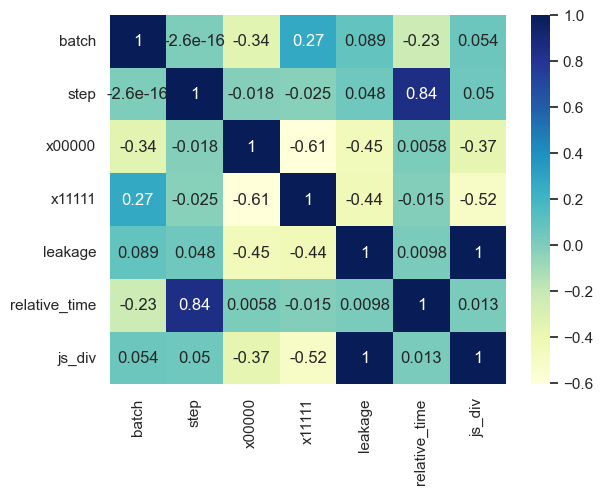

In [109]:
subset_df = data_df[data_df['device'] == 'Ankaa-3'][['batch', 'step', 'x00000', 'x11111', 'leakage', 'relative_time', 'js_div']]
sns.heatmap(
    data=subset_df.corr(numeric_only=True),
    cmap='YlGnBu',
    annot=True
)

<Axes: >

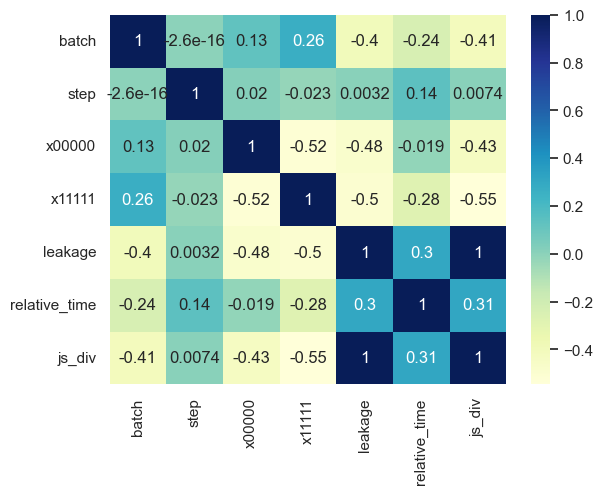

In [110]:
subset_df = data_df[data_df['device'] == 'Garnet'][['batch', 'step', 'x00000', 'x11111', 'leakage', 'relative_time', 'js_div']]
sns.heatmap(
    data=subset_df.corr(numeric_only=True),
    cmap='YlGnBu',
    annot=True
)

<Axes: >

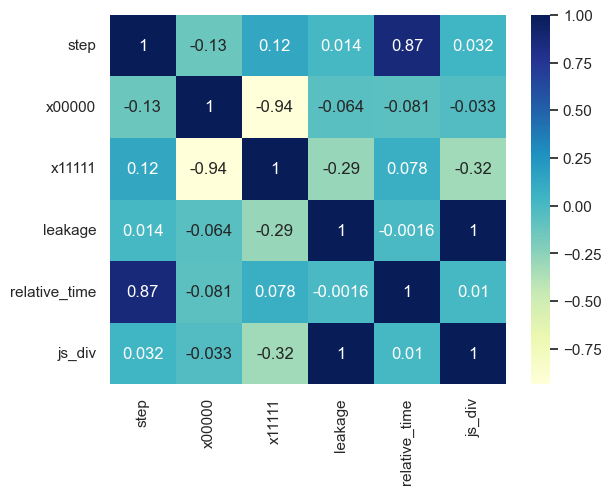

In [112]:
subset_df = data_df[data_df['device'] == 'Aria 1'][['step', 'x00000', 'x11111', 'leakage', 'relative_time', 'js_div']]
sns.heatmap(
    data=subset_df.corr(numeric_only=True),
    cmap='YlGnBu',
    annot=True
)

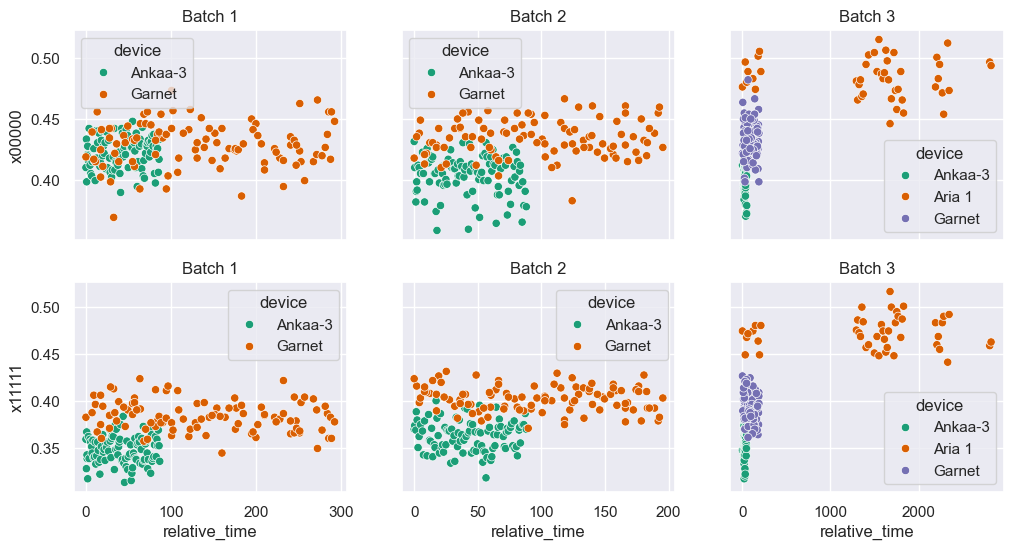

In [98]:
# Plot prob to measure each of 00000 and 11111.
fig, axes = plt.subplots(2, len(batch_keys), sharex='col', sharey='row', figsize=(4*len(batch_keys), 3*2))

for state, ax_row in zip(['x00000', 'x11111'], axes):
    for b, ax in zip(batch_keys, ax_row):
        # Plot.
        sns.scatterplot(
            data=grouped_by_batch_df.get_group(b),
            x='relative_time', y=state, hue='device',
            ax=ax
        )
        
        # Beautify.
        ax.set_title(f'Batch {b}')

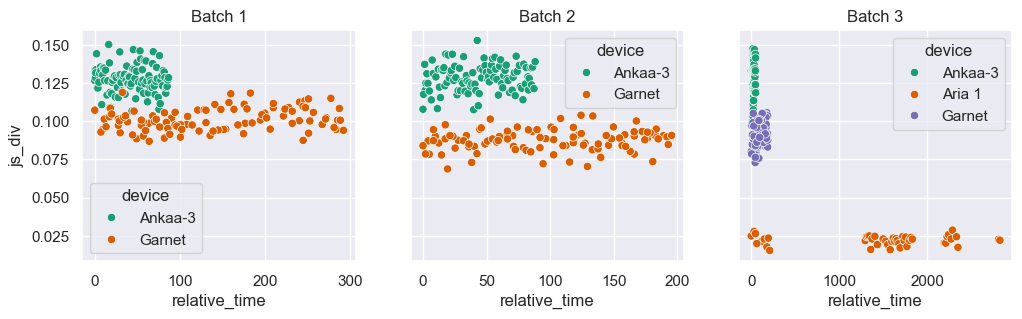

In [99]:
# Plot 'leakage' (prob to measure anything wrong) by step in each group, hued by device.
fig, axes = plt.subplots(1, len(batch_keys), sharey='row', figsize=(4*len(batch_keys), 3))

for b, ax in zip(batch_keys, axes):
    # Plot.
    sns.scatterplot(
        data=grouped_by_batch_df.get_group(b),
        x='relative_time', y='js_div', hue='device',
        ax=ax
    )
    
    # Beautify.
    ax.set_title(f'Batch {b}')

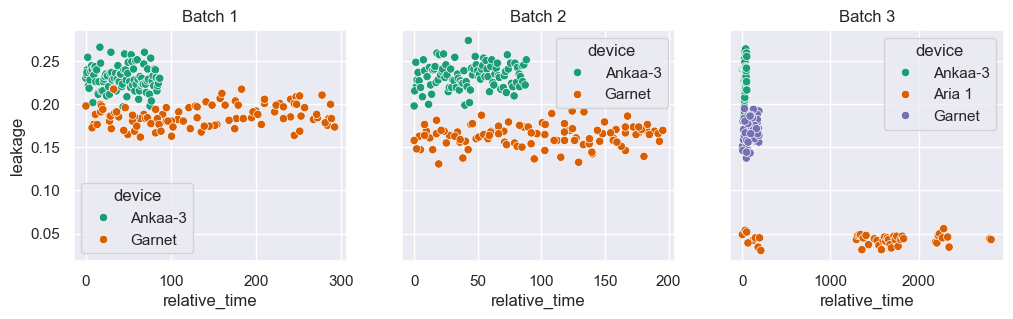

In [91]:
# Plot 'leakage' (prob to measure anything wrong) by step in each group, hued by device.
fig, axes = plt.subplots(1, len(batch_keys), sharey='row', figsize=(4*len(batch_keys), 3))

for b, ax in zip(batch_keys, axes):
    # Plot.
    sns.scatterplot(
        data=grouped_by_batch_df.get_group(b),
        x='relative_time', y='leakage', hue='device',
        ax=ax
    )
    
    # Beautify.
    ax.set_title(f'Batch {b}')

In [94]:
# Distribution data.
subset_df = data_df[data_df['device'] == 'Ankaa-3']
xs = subset_df[['x' + format(i, f'0{5}b') for i in range(2 ** 5)]]

# 2D dimensionality reduction (PCA and t-SNE)
pca, tsne = PCA(n_components=2), TSNE(n_components=2)
xs_pca, xs_tsne = pca.fit_transform(xs), tsne.fit_transform(xs)

# Create dataframes for them (makes it easier to hue).
pca_data = pd.DataFrame(
    {'x' : xs_pca[:,0], 'y' : xs_pca[:,1], 'Batch' : subset_df['batch'], 'Step' : subset_df['step'], 'Device' : subset_df['device']}
)
tsne_data = pd.DataFrame(
    {'x' : xs_tsne[:,0], 'y' : xs_tsne[:,1], 'Batch' : subset_df['batch'], 'Step' : subset_df['step'], 'Device' : subset_df['device']}
)

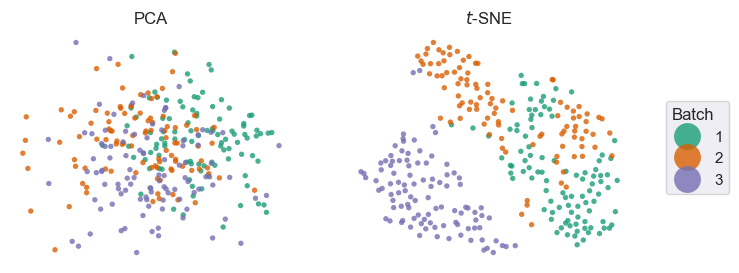

In [95]:
# Scatter plot the distributions in the reduced space (hue on machine).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
size = 15
alpha = .8
plot1 = sns.scatterplot(data=pca_data, x='x', y='y', hue='Batch', ax=ax1, s=size, linewidth=0, alpha=alpha, palette=palette)
plot2 = sns.scatterplot(data=tsne_data, x='x', y='y', hue='Batch', ax=ax2, s=size, linewidth=0, alpha=alpha, palette=palette)

# Beautification.
ax1.set_title('PCA')
ax2.set_title('$t$-SNE')

ax1.set_axis_off()
ax2.set_axis_off()

ax1.get_legend().remove()
legend = ax2.legend(title='Batch', loc='center left', bbox_to_anchor=(1.1, 0.5), markerscale=5)
legend._legend_box.align = "left"